# 05. Applying Supervised Learning Algorithms (Logistic Regression)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply logistic regression to labeled data
- Understand supervised learning
- Train classification models
- Evaluate model performance
- Apply to binary and multi-class problems

## 🔗 Prerequisites

- ✅ Understanding of supervised learning
- ✅ Understanding of logistic regression
- ✅ Scikit-learn knowledge

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Applying supervised learning algorithms on labeled data (e.g., logistic regression)

---

## Introduction

**Supervised learning** uses labeled data to train models that can predict outcomes, with logistic regression being a fundamental algorithm for classification tasks.

## The Story

**BEFORE**: You know linear regression but don't understand classification models.

**AFTER**: You'll learn logistic regression - the foundation of classification, understanding probabilities and decision boundaries!

**Why this matters**: Applying Supervised Learning Algorithms (Logistic Regression) is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Features X, binary target y
- sklearn

**Outputs:** What you'll see when you run the cells

- Logistic model
- Metrics
- Plots

---

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Libraries imported!")
print("\nSupervised Learning: Logistic Regression")
print("=" * 60)
print("""
Supervised learning recap (from Course 04 - AIAT 114):
  - We learn from LABELED data: features X plus known answers y
  - The model finds the mapping X -> y, then predicts y for new X
  - Logistic regression is the classic CLASSIFICATION baseline:
    it outputs P(class) via the sigmoid function, then thresholds it
""")

✅ Libraries imported!

Supervised Learning: Logistic Regression

Supervised learning recap (from Course 04 - AIAT 114):
  - We learn from LABELED data: features X plus known answers y
  - The model finds the mapping X -> y, then predicts y for new X
  - Logistic regression is the classic CLASSIFICATION baseline:
    it outputs P(class) via the sigmoid function, then thresholds it



## Part 1: Binary Classification — Train and Evaluate

We create a small labeled dataset (two features, two classes), split it into
train/test, fit a logistic regression model, and evaluate it — the complete
supervised workflow in one pass.

In [2]:
print("Part 1: Binary classification")
print("-" * 60)

# Labeled data: two informative features, two classes
np.random.seed(42)
n = 400
X = np.vstack([
    np.random.randn(n // 2, 2) + [2, 2],    # class 0 cluster
    np.random.randn(n // 2, 2) + [-1, -1],  # class 1 cluster
])
y = np.array([0] * (n // 2) + [1] * (n // 2))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Training samples: {len(X_train)}, test samples: {len(X_test)}")

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {acc:.2%}")
print("\nConfusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

# The part linear regression could not give us: real probabilities
proba = model.predict_proba(X_test[:5])
print("Predicted probabilities for the first 5 test samples:")
for i, (p0, p1) in enumerate(proba):
    print(f"  sample {i}: P(class 0)={p0:.3f}  P(class 1)={p1:.3f}  -> predicted {y_pred[i]}")

Part 1: Binary classification
------------------------------------------------------------
Training samples: 300, test samples: 100

Test accuracy: 97.00%

Confusion matrix (rows=actual, cols=predicted):
[[49  1]
 [ 2 48]]

Classification report:
              precision    recall  f1-score   support

           0      0.961     0.980     0.970        50
           1      0.980     0.960     0.970        50

    accuracy                          0.970       100
   macro avg      0.970     0.970     0.970       100
weighted avg      0.970     0.970     0.970       100

Predicted probabilities for the first 5 test samples:
  sample 0: P(class 0)=0.000  P(class 1)=1.000  -> predicted 1
  sample 1: P(class 0)=1.000  P(class 1)=0.000  -> predicted 0
  sample 2: P(class 0)=0.997  P(class 1)=0.003  -> predicted 0
  sample 3: P(class 0)=1.000  P(class 1)=0.000  -> predicted 0
  sample 4: P(class 0)=1.000  P(class 1)=0.000  -> predicted 0


## Part 2: The Decision Boundary

Logistic regression learns a boundary where P(class 1) = 0.5. Let's draw it.

Part 2: Visualizing the decision boundary
------------------------------------------------------------


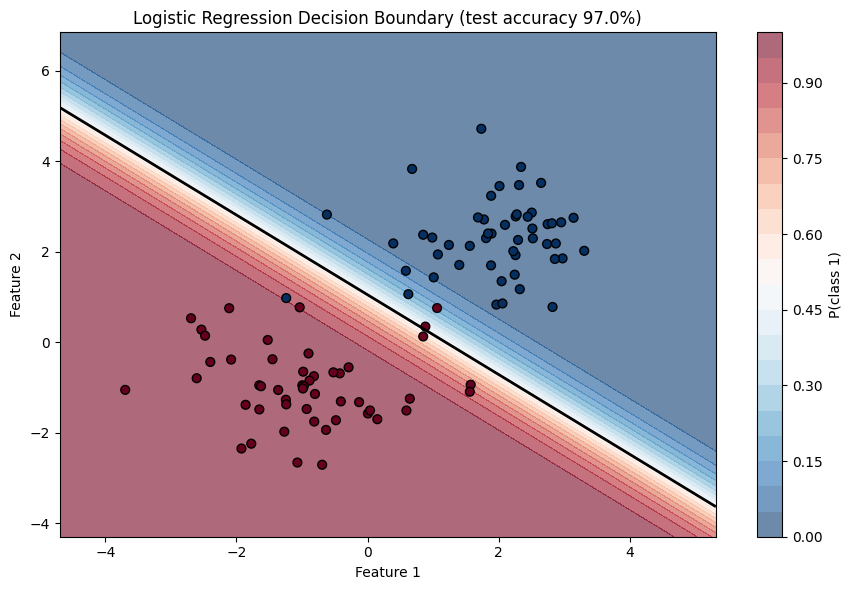

✓ Decision boundary plotted (black line = P(class 1) = 0.5)


In [3]:
print("Part 2: Visualizing the decision boundary")
print("-" * 60)

xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(class 1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu_r',
            edgecolors='black', s=40)
plt.title(f'Logistic Regression Decision Boundary (test accuracy {acc:.1%})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()
print("✓ Decision boundary plotted (black line = P(class 1) = 0.5)")

## Part 3: Multi-class Classification

The same estimator handles more than two classes — scikit-learn extends
logistic regression to multi-class automatically.

In [4]:
print("Part 3: Multi-class classification")
print("-" * 60)

X_mc, y_mc = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=7)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mc, y_mc, test_size=0.25, random_state=7, stratify=y_mc)

mc_model = LogisticRegression()
mc_model.fit(Xm_train, ym_train)
mc_acc = accuracy_score(ym_test, mc_model.predict(Xm_test))

print(f"Classes: {sorted(np.unique(y_mc))}")
print(f"Multi-class test accuracy: {mc_acc:.2%}")
proba3 = mc_model.predict_proba(Xm_test[:3])
print("\nPer-class probabilities for 3 test samples (rows sum to 1):")
for row in proba3:
    print("  " + "  ".join(f"{p:.3f}" for p in row))

Part 3: Multi-class classification
------------------------------------------------------------
Classes: [np.int64(0), np.int64(1), np.int64(2)]
Multi-class test accuracy: 100.00%

Per-class probabilities for 3 test samples (rows sum to 1):
  0.000  0.000  1.000
  0.000  0.991  0.009
  0.000  0.002  0.998


In [5]:
print("=" * 60)
print("Summary")
print("=" * 60)
print(f"""
What we actually did in this notebook:
  1. Trained a logistic regression classifier on labeled data
     -> binary test accuracy: {acc:.2%}
  2. Evaluated it: accuracy, confusion matrix, classification report
  3. Read real probabilities from predict_proba (unlike linear regression)
  4. Visualized the learned decision boundary
  5. Extended the same model to 3 classes -> accuracy: {mc_acc:.2%}

Next: Example 06 compares logistic regression against decision trees
with confusion matrices and ROC curves.
""")
print("✅ Supervised learning with logistic regression - complete!")

Summary

What we actually did in this notebook:
  1. Trained a logistic regression classifier on labeled data
     -> binary test accuracy: 97.00%
  2. Evaluated it: accuracy, confusion matrix, classification report
  3. Read real probabilities from predict_proba (unlike linear regression)
  4. Visualized the learned decision boundary
  5. Extended the same model to 3 classes -> accuracy: 100.00%

Next: Example 06 compares logistic regression against decision trees
with confusion matrices and ROC curves.

✅ Supervised learning with logistic regression - complete!
